# Mediapipe pose detection model

In [ ]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

import mediapipe as mp
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

<img src="pose_landmarks_index.png" width="400">


For each point: 

- x: Horizontal position (normalized between 0 and 1 relative to image width)
- y: Vertical position (normalized between 0 and 1 relative to image height)
- z: Depth value (relative to the image plane; negative means closer to the camera)
- visibility: Probability (0 to 1) that this landmark is visible
- presence: Probability (0 to 1) that this landmark exists in the frame'


COMPLEXITY
- 0 (Lightweight model, faster, less accurate)
- 1 (Default, balanced accuracy and speed)
- 2 (Heavy model, most accurate, slower)

min_detection_confidence (float, default=0.5)

The minimum confidence required to detect a person before pose landmarks are estimated.



In [10]:
help(mp.solutions.pose.Pose)

Help on class Pose in module mediapipe.python.solutions.pose:

class Pose(mediapipe.python.solution_base.SolutionBase)
 |  Pose(static_image_mode=False, model_complexity=1, smooth_landmarks=True, enable_segmentation=False, smooth_segmentation=True, min_detection_confidence=0.5, min_tracking_confidence=0.5)
 |  
 |  MediaPipe Pose.
 |  
 |  MediaPipe Pose processes an RGB image and returns pose landmarks on the most
 |  prominent person detected.
 |  
 |  Please refer to https://solutions.mediapipe.dev/pose#python-solution-api for
 |  usage examples.
 |  
 |  Method resolution order:
 |      Pose
 |      mediapipe.python.solution_base.SolutionBase
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, static_image_mode=False, model_complexity=1, smooth_landmarks=True, enable_segmentation=False, smooth_segmentation=True, min_detection_confidence=0.5, min_tracking_confidence=0.5)
 |      Initializes a MediaPipe Pose object.
 |      
 |      Args:
 |        static_i

In [ ]:
# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(static_image_mode=True, min_tracking_confidence=0.8)

In [ ]:
# !wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

Model downloaded successfully.


In [ ]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected poses to visualize.
  for idx in range(len(pose_landmarks_list)):
    pose_landmarks = pose_landmarks_list[idx]

    # Draw the pose landmarks.
    pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    pose_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in pose_landmarks
    ])
    #solutions.drawing_utils.draw_landmarks(
    mp_drawing.draw_landmarks(
      annotated_image,
      pose_landmarks_proto,
      solutions.pose.POSE_CONNECTIONS,
      #solutions.drawing_styles.get_default_pose_landmarks_style()
      mp_drawing.DrawingSpec(color=(0,255,0), thickness=4, circle_radius=5),  # Increased thickness & radius
      mp_drawing.DrawingSpec(color=(255,0,0), thickness=3, circle_radius=5)
      )
  return annotated_image

In [12]:
# Read the file contents
with open(r"C:\Users\propietari\sintesisII\pose_landmarker.task", "rb") as f:
    model_buffer = f.read()

base_options = python.BaseOptions(model_asset_buffer=model_buffer)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True
)

detector = vision.PoseLandmarker.create_from_options(options)

In [ ]:
# Define input and output directories
input_folder = r"C:\Users\propietari\sintesisII\FullDataset\40\23.10.24"
output_folder = r"C:\Users\propietari\sintesisII\FullDataset\model2\400"
no_detection = r"C:\Users\propietari\sintesisII\FullDataset\model2\400\No_Detection"

os.makedirs(output_folder, exist_ok=True)
os.makedirs(no_detection, exist_ok=True)

# Get all images with "VIS" in the filename (excluding thermal images)
image_paths = [os.path.join(root, file)
               for root, _, files in os.walk(input_folder)
               for file in files if "VIS" in file and file.lower().endswith(('.jpg', '.jpeg', '.png'))]

image_paths = image_paths[:-50]

for image_path in image_paths:
    # Load image
    image = mp.Image.create_from_file(image_path)
    image_np = image.numpy_view()

    # Detect pose landmarks
    detection_result = detector.detect(image)
    print(detection_result.pose_landmarks)

    # Generate annotated image
    annotated_image = draw_landmarks_on_image(image_np, detection_result)

    # Get segmentation mask
    if detection_result.segmentation_masks:
        segmentation_mask = detection_result.segmentation_masks[0].numpy_view()
        mask_vis = (segmentation_mask * 255).astype(np.uint8)
        mask_vis = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2BGR)
    else:
        mask_vis = None
    
    #create txt file with the coordinates of the landmarks
    if len(detection_result.pose_landmarks) > 0:
        with open(os.path.join(output_folder, f"landmarks_{os.path.basename(image_path)}.txt"), 'w') as f:
            for landmark in detection_result.pose_landmarks[0]:
                f.write(f"{landmark.x}, {landmark.y}, {landmark.z}, {landmark.presence}, {landmark.visibility} \n")
    # Save images
    if len(detection_result.pose_landmarks) > 0:
        filename = os.path.basename(image_path)
        original_out = os.path.join(output_folder, f"original_{filename}")
        annotated_out = os.path.join(output_folder, f"keypoints_{filename}")
        mask_out = os.path.join(output_folder, f"mask_{filename}")
        #cv2.imwrite(original_out, cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))  # Convert RGB to BGR for OpenCV
        cv2.imwrite(annotated_out, cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
        #cv2.imwrite(mask_out, mask_vis)
    else:
        filename = os.path.basename(image_path)
        print(f"No detection for {image_path}. Saving original image.")
        original_out = os.path.join(no_detection, f"original_{filename}")
        cv2.imwrite(original_out, cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))

print(f"Processing complete. Results saved in {output_folder}")

## Orientation 

l'output del model amb les imatges del nen 29 surten amb una rotació de 90 graus cap a la dreta. la cosa és que a la galeria les imatges es veuen verticals, tant les normals com les tèrmiques. en canvi, un cop les carregues a python les imatges es giren cap a la dreta. 

això era per comprovar que no tinguessim problemes amb les coordenades a l'hora de passar de la foto normal a la tèrmica. 

encara que giris les imatges a la galeria, python carrega les imatges amb la seva metadata corresponent. 

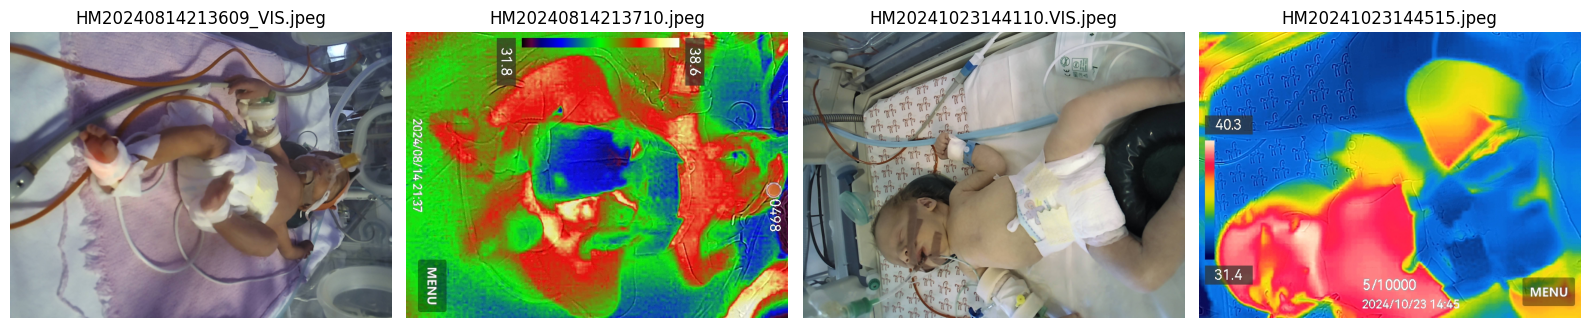

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

# List of image paths
image_paths = [
    "C:/Users/propietari/sintesisII/FullDataset/29/14.08.24-15.08.24/HM20240814213609_VIS.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/29/14.08.24-15.08.24/HM20240814213710.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/40/23.10.24/HM20241023144110.VIS.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/40/23.10.24/HM20241023144515.jpeg"
]

# Load images
images = [Image.open(path) for path in image_paths]

# Display images side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, path in zip(axes, images, image_paths):
    ax.imshow(img)
    ax.set_title(path.split('/')[-1])  # Show only the filename
    ax.axis("off")

plt.tight_layout()
plt.show()

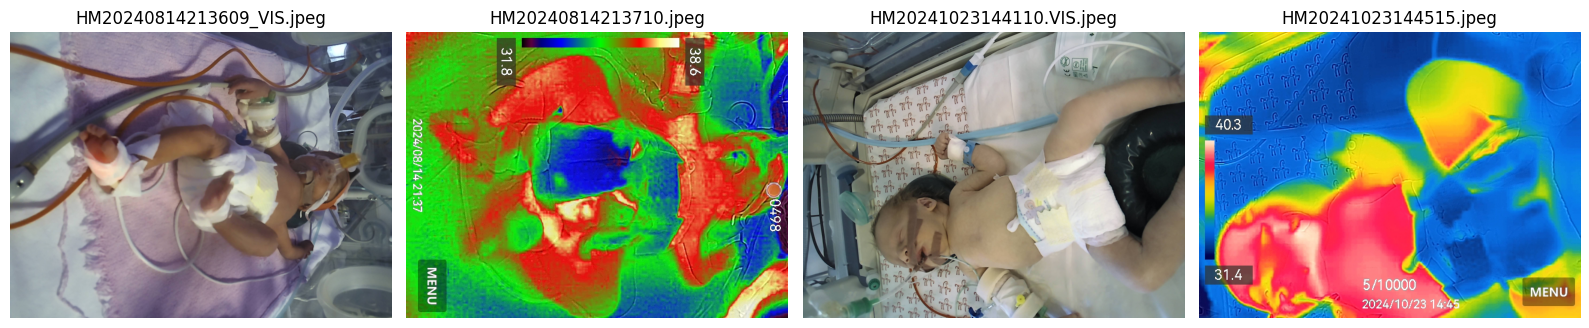

In [20]:
import mediapipe as mp
import matplotlib.pyplot as plt

# List of image paths
image_paths = [
    "C:/Users/propietari/sintesisII/FullDataset/29/14.08.24-15.08.24/HM20240814213609_VIS.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/29/14.08.24-15.08.24/HM20240814213710.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/40/23.10.24/HM20241023144110.VIS.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/40/23.10.24/HM20241023144515.jpeg"
]

mp_image = mp.Image
images = [mp_image.create_from_file(path) for path in image_paths]

fig, axes = plt.subplots(1, len(images), figsize=(16, 4))
for ax, img, path in zip(axes, images, image_paths):
    ax.imshow(img.numpy_view())  
    ax.set_title(path.split('/')[-1])  
    ax.axis("off")

plt.tight_layout()
plt.show()


cv2 no utilitza la metadata

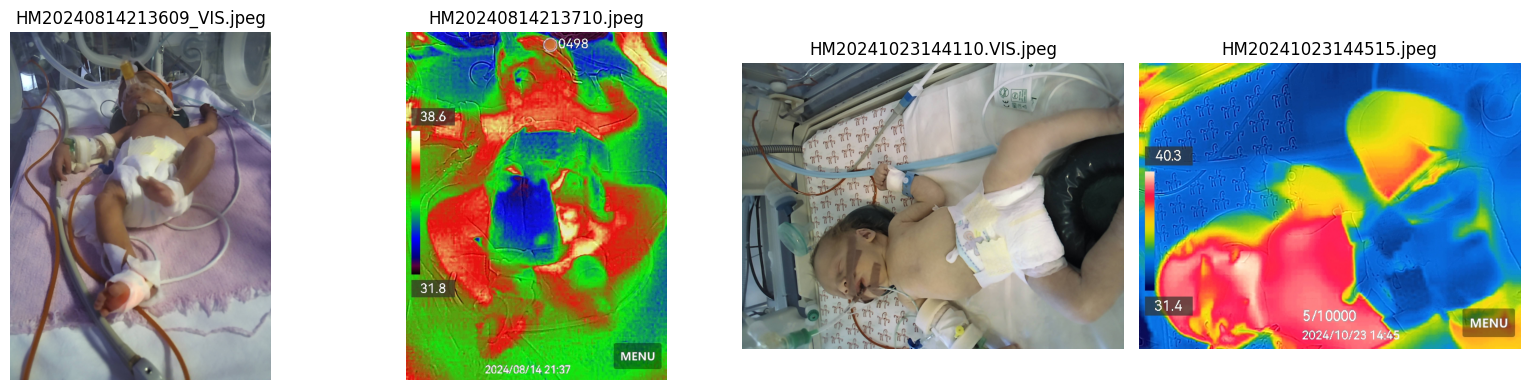

In [21]:
import cv2
import matplotlib.pyplot as plt

# List of image paths
image_paths = [
    "C:/Users/propietari/sintesisII/FullDataset/29/14.08.24-15.08.24/HM20240814213609_VIS.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/29/14.08.24-15.08.24/HM20240814213710.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/40/23.10.24/HM20241023144110.VIS.jpeg",
    "C:/Users/propietari/sintesisII/FullDataset/40/23.10.24/HM20241023144515.jpeg"
]

# Load images using OpenCV
images = [cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB) for path in image_paths]

# Display images side by side
fig, axes = plt.subplots(1, len(images), figsize=(16, 4))
for ax, img, path in zip(axes, images, image_paths):
    ax.imshow(img)  # Display OpenCV image
    ax.set_title(path.split('/')[-1])  # Show only the filename
    ax.axis("off")

plt.tight_layout()
plt.show()